# Check: `hValGrid` is built and plotted

Builds the `h_val_grid` (eigenvalues of `H_perp` vs epoch, across replicas) via the
API and plots it with colibri's generic `ntk_plot_provider`, asserting that at least
one figure is produced.

Note: `h_val_grid` runs the NTK decomposition at **every stored epoch**, so it can be
slow / memory-heavy. Pass `custom_epochs=[...]` (epochs with saved weights) to limit it.

In [1]:
%matplotlib inline
from functools import partial
from IPython.display import display

from ntkpdf.api import API
from ntkpdf.utils import EVOL_LIST

import logging
logging.basicConfig(level=logging.INFO)

Applying NTKPDF plotting style...
Using Keras backend


In [2]:
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)
fit = "260527-ac-01-ntk-sgd"

In [ ]:
# Build the h_val grid (hValGrid). `name`/`evol_fl_names` match the decomposition
# call in test.ipynb. Add custom_epochs=[...] to restrict to a few saved epochs.
h_grid = API.h_val_grid(
    fit=fit,
    **common_dict,
    training=True,
    name="model",
    evol_fl_names=EVOL_LIST,
    custom_epochs=[500, 1000, 2000, 5000]
)
print(type(h_grid).__name__, "| epochs:", h_grid.epochs, "| n_ranks:", h_grid.n_ranks)

Produced 1 figure(s)


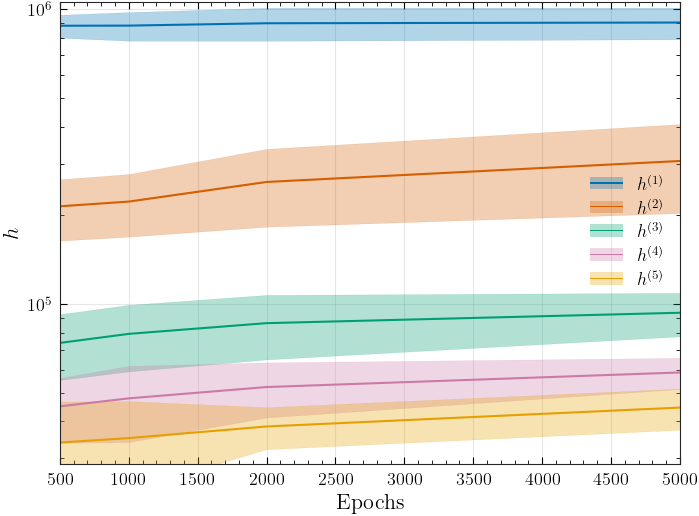

In [4]:
# Plot with colibri's generic NTK plot provider: one figure overlaying the top
# h-ranks vs epoch. hValGrid is an NTKGrid, so this works unchanged.
from colibri.ntk.plotntk import ntk_plot_provider, iter_by_fit, draw_band

gen = ntk_plot_provider(
    [h_grid],
    rank_indices=[1, 2, 3, 4, 5],
    iterator_fn=iter_by_fit,
    draw_fn=partial(draw_band, error_type="mean"),
    name_fn=lambda g: f"h_val_{g.label}",
    ylabel_fn=lambda g: r"$h$",
    xscale="linear",
    yscale="log",
)

figs = list(gen)
print(f"Produced {len(figs)} figure(s)")
assert len(figs) > 0, "No figure produced by ntk_plot_provider"

for fig, _result in figs:
    display(fig)

# Plots of single replicas

In [10]:
figs = API.plot_feature_eigvals_replica_by_fit(fits=[fit],
                                        replica_index=1,
                                        **common_dict,
                                        rank_indices=[1,2,3])

INFO:colibri.ntk.eigenvalues:All 3 replicas already computed. Loading from cache.
INFO:colibri.ntk.ntkutils:Loaded eigenvalues ensemble: 3 replicas, 1000 epochs


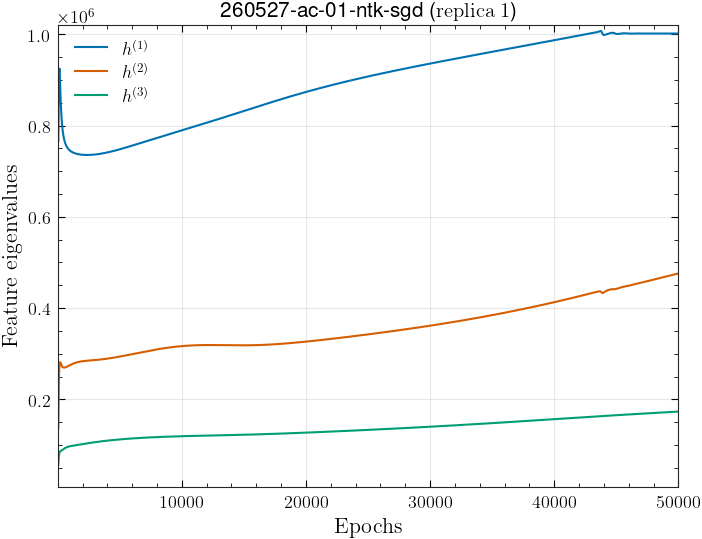

In [11]:
for fig, _result in figs:
    display(fig)